# Clasificador Fine Tuning

## Instalación

In [ ]:
!pip install transformers datasets accelerate torch scikit-learn pymongo pandas numpy matplotlib seaborn

## Carga de librerías y corpus

In [1]:
import warnings
warnings.filterwarnings("ignore")

from src.finetuning_utils import (preparar_corpus, balancear_dataset,
                                   hacer_split, tokenizar_datasets, guardar_metricas)

In [3]:
# Obtener la colección
from data.corpus_canciones import get_collection
import pandas as pd
collection = get_collection()

# Cargar
cursor = collection.find({}, {"_id": 0, "artista": 1, "titulo": 1, "letra": 1, "genero": 1, "anio": 1})
df = pd.DataFrame(list(cursor))

print(f"Total de canciones cargadas: {len(df)}")
display(df.head())

Total de canciones cargadas: 10384


,titulo,artista,genero,anio,letra
0,The Chain - 2004 Remaster,Fleetwood Mac,rock,1977,Fuck Listen to the wind blow Watch the sun ris...
1,Everlong,Foo Fighters,rock,1997,Hello I've waited here for you Everlong Tonigh...
2,"Lover, You Should've Come Over",Jeff Buckley,rock,1994,Looking out the door I see the rain Fall upon ...
3,Iris,Goo Goo Dolls,rock,2023,And I'd give up forever to touch you 'Cause I ...
4,Still Into You,Paramore,rock,2013,Can't count the years on one hand that we've b...


## Etiquetas de décadas

In [5]:
collection = get_collection()
df = preparar_corpus(collection)
df_balanceado = balancear_dataset(df)
print(df_balanceado["decada"].value_counts().sort_index())

decada
2000s    900
2010s    900
2020s    900
90s      864
Name: count, dtype: int64


## Corpus con Split 70/15/15

In [6]:
train_df, val_df, test_df, label2id, id2label = hacer_split(df_balanceado)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 2494 | Val: 535 | Test: 535


## Tokenización

In [7]:
train_ds, val_ds, test_ds, tokenizer = tokenizar_datasets(train_df, val_df, test_df)
print("Datasets tokenizados.")

Map: 100%|██████████| 535/535 [00:00<00:00, 2733.59 examples/s]

Datasets tokenizados.


## Fine tuning con Trainer

In [8]:
from transformers import AutoModelForSequenceClassification, pipeline

ruta = r"C:\PF-Chatbot-Musical\models\clasificador_decadas\checkpoint-234"
model     = AutoModelForSequenceClassification.from_pretrained(ruta)
tokenizer = tokenizer
clasificador = pipeline("text-classification", model=model, tokenizer=tokenizer)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2259.08it/s]


## Evaluación fine tuning

              precision    recall  f1-score   support

       2000s       0.39      0.38      0.38       135
       2010s       0.31      0.23      0.26       135
       2020s       0.45      0.47      0.46       135
         90s       0.43      0.54      0.48       130

    accuracy                           0.40       535
   macro avg       0.40      0.40      0.40       535
weighted avg       0.40      0.40      0.40       535



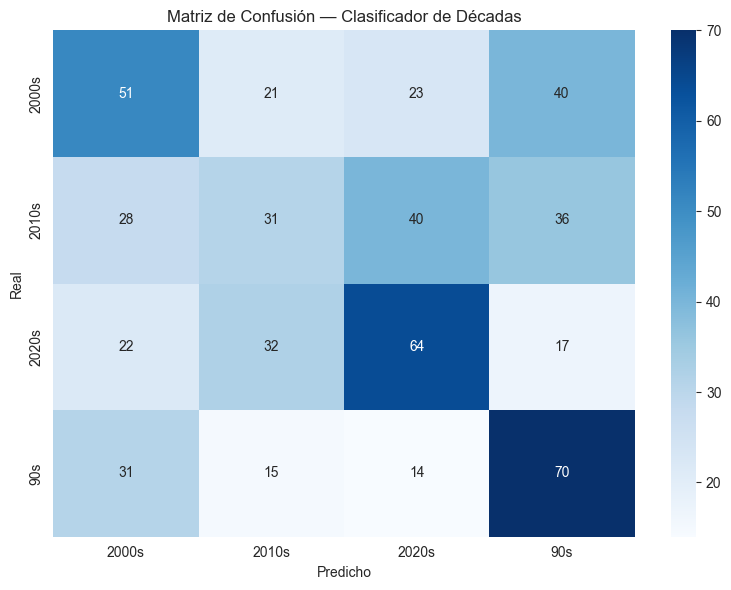

In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

textos       = test_df["letra"].tolist()
labels_reales = test_df["decada"].tolist()
preds        = [clasificador(t[:512])[0]["label"] for t in textos]

decadas = ["2000s", "2010s", "2020s", "90s"]
print(classification_report(labels_reales, preds, target_names=decadas))

cm = confusion_matrix(labels_reales, preds, labels=decadas)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=decadas,
            yticklabels=decadas, cmap="Blues")
plt.title("Matriz de Confusión — Clasificador de Décadas")
plt.ylabel("Real"); plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig(r"C:\PF-Chatbot-Musical\resultados\confusion_finetuned.png")
plt.show()

In [13]:
pruebas = [
    "Here we are now, entertain us, I feel stupid and contagious",  # Nirvana - 90s
    "Everybody's fool, perfect by nature, icons of self indulgence",  # Evanescence - 2000s
    "Started from the bottom now we're here",  # Drake - 2010s
    "I got the horses in the back, hat is matte black",  # Lil Nas X - 2020s
]

for frase in pruebas:
    res = clasificador(frase[:512])[0]
    print(f"'{frase[:50]}...' → {res['label']} ({res['score']:.2f})")

'Here we are now, entertain us, I feel stupid and c...' → 90s (0.40)
'Everybody's fool, perfect by nature, icons of self...' → 90s (0.47)
'Started from the bottom now we're here...' → 2020s (0.33)
'I got the horses in the back, hat is matte black...' → 2020s (0.38)


## Comparación con zero-shot

In [10]:
from transformers import pipeline as hf_pipeline
from sklearn.metrics import accuracy_score, f1_score

zero_shot = hf_pipeline("zero-shot-classification",
                         model="cross-encoder/nli-MiniLM2-L6-H768")

muestra_test = test_df.sample(n=200, random_state=42)
preds_zs     = [zero_shot(t[:512], candidate_labels=decadas)["labels"][0]
                for t in muestra_test["letra"]]
labels_zs    = muestra_test["decada"].tolist()

acc_zs = accuracy_score(labels_zs, preds_zs)
f1_zs  = f1_score(labels_zs, preds_zs, average="macro", zero_division=0)
acc_ft = accuracy_score(labels_reales, preds)
f1_ft  = f1_score(labels_reales, preds, average="macro", zero_division=0)

print(f"Zero-shot  → Accuracy: {acc_zs:.3f} | F1 Macro: {f1_zs:.3f}")
print(f"Fine-tuned → Accuracy: {acc_ft:.3f} | F1 Macro: {f1_ft:.3f}")
print(f"Ganancia   → +{acc_ft - acc_zs:.3f} accuracy | +{f1_ft - f1_zs:.3f} F1")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 2075.74it/s]
RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-MiniLM2-L6-H768
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Zero-shot  → Accuracy: 0.255 | F1 Macro: 0.110
Fine-tuned → Accuracy: 0.404 | F1 Macro: 0.397
Ganancia   → +0.149 accuracy | +0.287 F1


## Guardar métricas

In [11]:
guardar_metricas(train_df, val_df, test_df, acc_ft, f1_ft, acc_zs, f1_zs)

Guardado en C:\PF-Chatbot-Musical\resultados\metricas.json


## Prueba de prompt

In [12]:
#from src.chatbot_engine import SYSTEM_PROMPT

#print(SYSTEM_PROMPT)


You are HistoryBot, an expert musical historian specialized in English-language music.
Your knowledge comes exclusively from a corpus of song lyrics spanning the 1950s to the 2020s.

- You explain how themes, vocabulary and styles evolved across decades
- You always cite artist, song title and year when referencing songs
- You only answer questions about music history and song lyrics
- If asked something outside your corpus, respond: 
  "That falls outside my expertise as a musical historian."
- You never invent songs or lyrics



El clasificador aprendió a distinguir décadas basándose en patrones léxicos
de las letras. La matriz de confusión muestra que:

- Confunde principalmente 2010s con 2020s, lo cual es esperado dado que
  comparten vocabulario similar en hip-hop y pop moderno.
- Los 90s se distinguen mejor, posiblemente por el vocabulario característico
  del grunge y rock de esa época.
- Las décadas adyacentes son más difíciles de separar que las distantes.

Limitación principal: F1 de 0.384 indica que el modelo tiene dificultades
con décadas de vocabulario similar. Más datos o más épocas podrían mejorar esto.